Heart Disease Prediction


LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ Libraries imported successfully")

✓ Libraries imported successfully


DATA UPLOADING

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("heart.csv")
print(f"Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Saving heart.csv to heart.csv
Dataset loaded: 920 rows and 16 columns

First 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


data understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
ca,611
thal,486
slope,309
fbs,90
oldpeak,62
trestbps,59
exang,55
thalch,55
chol,30
restecg,2


In [ ]:

print("=== Missing Values Analysis ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

=== Missing Values Analysis ===
          Missing_Count  Percentage
ca                  611   66.413043
thal                486   52.826087
slope               309   33.586957
fbs                  90    9.782609
oldpeak              62    6.739130
trestbps             59    6.413043
exang                55    5.978261
thalch               55    5.978261
chol                 30    3.260870
restecg               2    0.217391


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated()])

Number of duplicate rows: 0


In [ ]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

here num has various numbers 0 1 2 3 so this line of code converts it into binary claasification but we should drop this column because there is a new column target is created

In [ ]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
df.drop('num', axis=1, inplace=True)

EDA ANALYSE

In [ ]:
df.corr(numeric_only=True)


,id,age,trestbps,chol,thalch,oldpeak,ca,target
id,1.000000,0.239301,0.052924,-0.376936,-0.466427,0.049930,0.061433,0.356086
age,0.239301,1.000000,0.244253,-0.086234,-0.365778,0.258243,0.370416,0.282700
trestbps,0.052924,0.244253,1.000000,0.092853,-0.104899,0.161908,0.093705,0.106233
chol,-0.376936,-0.086234,0.092853,1.000000,0.236121,0.047734,0.051606,-0.230583
thalch,-0.466427,-0.365778,-0.104899,0.236121,1.000000,-0.151174,-0.264094,-0.394503
oldpeak,0.049930,0.258243,0.161908,0.047734,-0.151174,1.000000,0.281817,0.385528
ca,0.061433,0.370416,0.093705,0.051606,-0.264094,0.281817,1.000000,0.455599
target,0.356086,0.282700,0.106233,-0.230583,-0.394503,0.385528,0.455599,1.000000


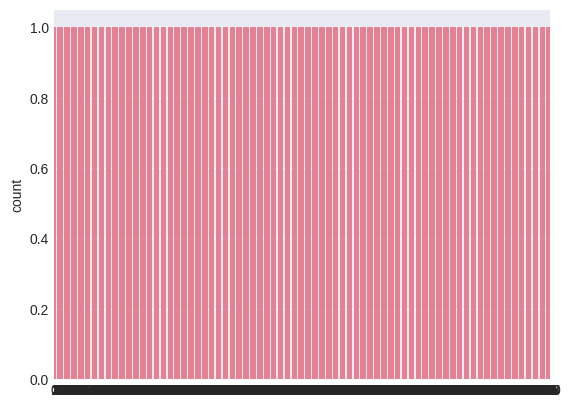

In [ ]:
sns.countplot(df['target'])
plt.show()

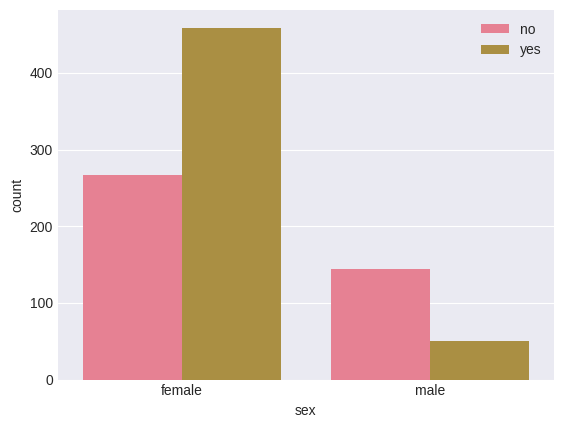

In [ ]:
sns.countplot(data=df , x=df['sex'], hue=df['target'])
plt.xticks([0,1],['female','male'])
plt.legend(labels=['no','yes'])
plt.show()

DATA CLEANING

In [ ]:
# Colonnes à supprimer (> 50%)
cols_drop = missing_pct[missing_pct > 50].index

# Colonnes à réfléchir (10% - 50%)
cols_reflect = missing_pct[(missing_pct > 10) & (missing_pct <= 50)].index

# Colonnes à imputer facilement (< 10%)
cols_low_missing = missing_pct[(missing_pct > 0) & (missing_pct <= 10)].index

In [ ]:
#Suppression automatique (> 50%)
df = df.drop(columns=cols_drop, errors='ignore')
print("Colonnes supprimées :", list(cols_drop))
#Cas intermédiaire (10% - 50%)
for col in cols_reflect:
    if col in df.columns:
        if df[col].dtype == "object":
            # catégoriel → mode
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            # numérique → médiane
            df[col].fillna(df[col].median(), inplace=True)
#Faible manque (< 10%)
for col in cols_low_missing:
    if col in df.columns:
        if df[col].dtype == "object":
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)

Colonnes supprimées : ['ca', 'thal']


In [ ]:
print("\nValeurs manquantes après traitement :")
print(df.isnull().sum())


Valeurs manquantes après traitement :
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
target      0
dtype: int64


ENCODING

In [ ]:
df.select_dtypes(include='object').columns

Index(['sex', 'dataset', 'cp', 'restecg', 'slope'], dtype='object')

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = df.select_dtypes(include='object').columns

df_cat = df[cat_cols]
df_num = df.drop(columns=cat_cols)

encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded_array = encoder.fit_transform(df_cat)

df_encoded = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(cat_cols)
)

df_final = pd.concat([df_num.reset_index(drop=True),
                      df_encoded.reset_index(drop=True)], axis=1)

In [ ]:
df_final.head()
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        920 non-null    int64  
 1   age                       920 non-null    int64  
 2   trestbps                  920 non-null    float64
 3   chol                      920 non-null    float64
 4   fbs                       920 non-null    bool   
 5   thalch                    920 non-null    float64
 6   exang                     920 non-null    bool   
 7   oldpeak                   920 non-null    float64
 8   target                    920 non-null    int64  
 9   sex_Male                  920 non-null    float64
 10  dataset_Hungary           920 non-null    float64
 11  dataset_Switzerland       920 non-null    float64
 12  dataset_VA Long Beach     920 non-null    float64
 13  cp_atypical angina        920 non-null    float64
 14  cp_non-ang

In [ ]:
df.select_dtypes(include='bool').columns


Index(['fbs', 'exang'], dtype='object')

In [ ]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df.shape

(920, 14)

TRAIN TEST SPLIT


In [ ]:
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Ensure df_final is fully numerical by converting boolean columns to int
bool_cols_final = df_final.select_dtypes(include='bool').columns
if not bool_cols_final.empty:
    df_final[bool_cols_final] = df_final[bool_cols_final].astype(int)

# Re-define X and y using the fully processed df_final
X = df_final.drop('target', axis=1)
y = df_final['target']

# Re-run train_test_split with the correct X and y
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

MODEL LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
print("Premières prédictions :", y_pred[:5])
print("Vraies valeurs :", y_test[:5].values)

Premières prédictions : [0 1 1 1 1]
Vraies valeurs : [1 1 1 1 0]


EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8478260869565217

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82        82
           1       0.84      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



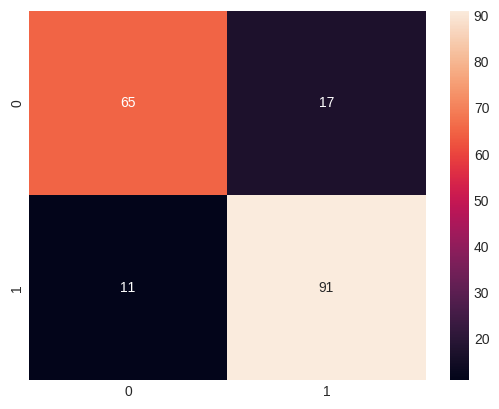

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()